# CRAWLING DATA

In [ ]:
# INSTALL DEPENDENSI
# Instalasi pandas dan Node.js v20 yang dibutuhkan oleh tweet-harvest

!pip install pandas -q

!sudo apt-get update -q
!sudo apt-get install -y ca-certificates curl gnupg -q
!sudo mkdir -p /etc/apt/keyrings
!curl -fsSL https://deb.nodesource.com/gpgkey/nodesource-repo.gpg.key \
    | sudo gpg --dearmor -o /etc/apt/keyrings/nodesource.gpg
!NODE_MAJOR=20 && echo "deb [signed-by=/etc/apt/keyrings/nodesource.gpg] \
    https://deb.nodesource.com/node_$NODE_MAJOR.x nodistro main" \
    | sudo tee /etc/apt/sources.list.d/nodesource.list
!sudo apt-get update -q
!sudo apt-get install nodejs -y -q
!node -v


In [ ]:
# CRAWLING CUITAN DARI PLATFORM X

TWITTER_AUTH_TOKEN = "79744989f8d8037d9cbaf2331ca3ab9997c5d7b0"

filename       = "Pertamina.csv"
search_keyword = "(Pertamina lang:id) until:2025-10-31 since:2025-09-01"
limit          = 10000

!npx -y tweet-harvest@2.6.1 \
    -o "{filename}" \
    -s "{search_keyword}" \
    --tab "LATEST" \
    -l {limit} \
    --token {TWITTER_AUTH_TOKEN}


# DATA PREPARATION

In [ ]:
# LOAD DATASET

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

BASE      = '/content/drive/MyDrive/Proposal Skripsi/dataset/'
FILE_PATH = BASE + 'Salinan Pertamina_All.csv'

df_raw = pd.read_csv(FILE_PATH)

print(f"Dataset berhasil dimuat.")
print(f"Jumlah baris : {len(df_raw):,}")
print(f"Kolom        : {list(df_raw.columns)}")
display(df_raw.head(10))


Mounted at /content/drive
Dataset berhasil dimuat.
Jumlah baris : 7,486
Kolom        : ['conversation_id_str', 'created_at', 'favorite_count', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username']


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1983546861517746602,Thu Oct 30 23:58:54 +0000 2025,0,@e100ss Marketing pertamina sukses menggiring ...,1984047389301469445,NaN,e100ss,in,NaN,0,0,0,https://x.com/undefined/status/198404738930146...,1135984686159675392,NaN
1,1984027176132616533,Thu Oct 30 23:57:21 +0000 2025,1,@tr1ey @Bambangmulyonoo @pertamina @bahlillaha...,1984047002523726154,NaN,tr1ey,in,NaN,0,0,0,https://x.com/undefined/status/198404700252372...,1315622738,NaN
2,1984046332164894741,Thu Oct 30 23:54:42 +0000 2025,0,kalau itu sudah sesuai standar berarti bensin ...,1984046332164894741,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/198404633216489...,1646345540333105153,NaN
3,1984046008117187026,Thu Oct 30 23:53:24 +0000 2025,0,Sejumlah warga masih mengeluhkan kondisi motor...,1984046008117187026,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/198404600811718...,1914885191933550593,NaN
4,1983809176322371942,Thu Oct 30 23:49:29 +0000 2025,0,@Jateng_Twit @pertamina Terus siapa yg diuntun...,1984045020899635467,NaN,wanitakon,in,NaN,0,0,0,https://x.com/undefined/status/198404502089963...,1602214268195442688,NaN
5,1983809176322371942,Thu Oct 30 23:47:47 +0000 2025,1,@Jateng_Twit @pertamina sengaja nder pertamina...,1984044594754134380,NaN,Jateng_Twit,in,NaN,0,2,0,https://x.com/undefined/status/198404459475413...,1602214268195442688,NaN
6,1984044032524435665,Thu Oct 30 23:45:33 +0000 2025,0,itu yg bawah kok bening ya bro? #Pertamina #Pe...,1984044032524435665,https://pbs.twimg.com/media/G4i9cUpaUAAYV1k.png,NaN,in,NaN,0,0,0,https://x.com/undefined/status/198404403252443...,1646345540333105153,NaN
7,1984037631341351396,Thu Oct 30 23:43:56 +0000 2025,1,@kompascom Fungsinya apa kalo kendaraan2 konsu...,1984043626599731553,NaN,kompascom,in,NaN,0,0,0,https://x.com/undefined/status/198404362659973...,183517457,NaN
8,1984042424772243734,Thu Oct 30 23:40:45 +0000 2025,2,gw lbh baik selamat sampai ditujuan dg kendara...,1984042825282154970,NaN,masduke_x,in,NaN,0,0,0,https://x.com/undefined/status/198404282528215...,3118025055,NaN
9,1983782441493131715,Thu Oct 30 23:38:19 +0000 2025,1,@pertamina pakai nomor WA. jangan 135. nomor 1...,1984042209117925646,NaN,pertamina,in,NaN,0,0,0,https://x.com/undefined/status/198404220911792...,2384764039,NaN


In [ ]:
# KONVERSI TANGGAL
# Mengubah kolom created_at dari format Twitter menjadi format tanggal standar

date_fmt = "%a %b %d %H:%M:%S %z %Y"
df_raw['created_at'] = pd.to_datetime(df_raw['created_at'], format=date_fmt)
df_raw['created_at'] = df_raw['created_at'].dt.date

print("Konversi tanggal selesai.")
display(df_raw[['created_at', 'full_text']].head(10))


Konversi tanggal selesai.


,created_at,full_text
0,2025-10-30,@e100ss Marketing pertamina sukses menggiring ...
1,2025-10-30,@tr1ey @Bambangmulyonoo @pertamina @bahlillaha...
2,2025-10-30,kalau itu sudah sesuai standar berarti bensin ...
3,2025-10-30,Sejumlah warga masih mengeluhkan kondisi motor...
4,2025-10-30,@Jateng_Twit @pertamina Terus siapa yg diuntun...
5,2025-10-30,@Jateng_Twit @pertamina sengaja nder pertamina...
6,2025-10-30,itu yg bawah kok bening ya bro? #Pertamina #Pe...
7,2025-10-30,@kompascom Fungsinya apa kalo kendaraan2 konsu...
8,2025-10-30,gw lbh baik selamat sampai ditujuan dg kendara...
9,2025-10-30,@pertamina pakai nomor WA. jangan 135. nomor 1...


In [ ]:
# FILTER BAHASA INDONESIA

df = df_raw[['created_at', 'full_text', 'lang']].copy()

print("Distribusi bahasa sebelum filter:")
print(df['lang'].value_counts().head(5).to_string())

df = df[df['lang'] == 'in'].reset_index(drop=True)

print(f"\nSetelah filter bahasa Indonesia : {len(df):,} cuitan")


Distribusi bahasa sebelum filter:
lang
in    7486

Setelah filter bahasa Indonesia : 7,486 cuitan


# PREPROCESSING

In [ ]:
# SETUP PREPROCESSING

import warnings
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', 90)

df_before_preprocessing = df[['created_at', 'full_text']].copy()
df_before_preprocessing.columns = ['Tanggal', 'Teks Mentah']

print("Data mentah tersimpan sebagai snapshot.")
print(f"Jumlah data : {len(df_before_preprocessing):,} baris")
print()
print("Contoh data mentah (10 baris pertama):")
display(df_before_preprocessing.head(10))


Data mentah tersimpan sebagai snapshot.
Jumlah data : 7,486 baris

Contoh data mentah (10 baris pertama):


,Tanggal,Teks Mentah
0,2025-10-30,@e100ss Marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamax...ki...
1,2025-10-30,@tr1ey @Bambangmulyonoo @pertamina @bahlillahadalia @prabowo lah kok pake nanya kebija...
2,2025-10-30,kalau itu sudah sesuai standar berarti bensin kalian yang busuk @pertamina @bahlillaha...
3,2025-10-30,Sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendat-sendat setel...
4,2025-10-30,@Jateng_Twit @pertamina Terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik ...
5,2025-10-30,@Jateng_Twit @pertamina sengaja nder pertamina memang sengaja dibikin mawut. Pom swast...
6,2025-10-30,itu yg bawah kok bening ya bro? #Pertamina #Pertalite #bahlil #brebet https://t.co/jYi...
7,2025-10-30,@kompascom Fungsinya apa kalo kendaraan2 konsumen udah banyak yg dirusak karna kualita...
8,2025-10-30,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...
9,2025-10-30,@pertamina pakai nomor WA. jangan 135. nomor 135 kan habisin pulsa aja. apa gratis beb...


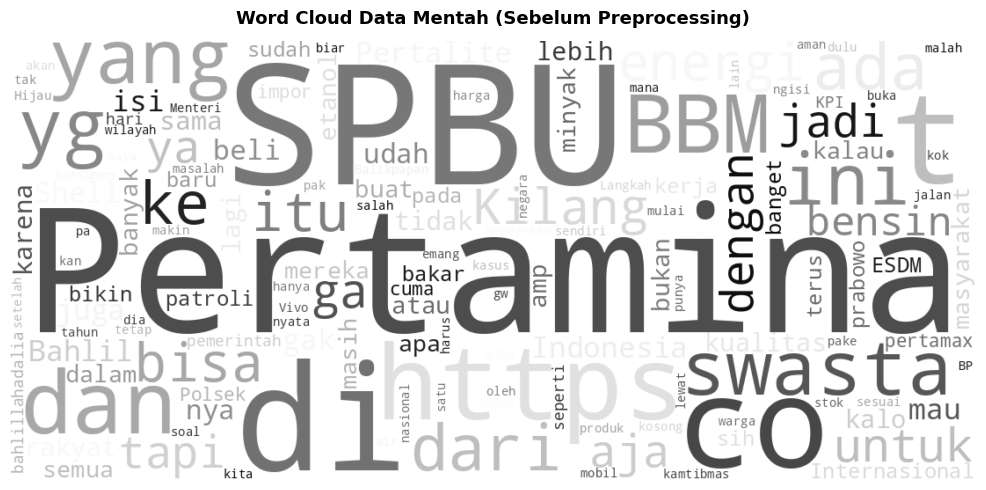

Word cloud disimpan : /content/drive/MyDrive/Proposal Skripsi/dataset/viz_wc_raw.png


In [ ]:
def make_wordcloud(text_series, title, savepath, colormap='Blues'):
    """Buat dan simpan word cloud dari pandas Series teks."""
    text = ' '.join(text_series.dropna().astype(str))
    if not text.strip():
        print(f"[SKIP] Tidak ada teks untuk: {title}")
        return
    wc = WordCloud(
        width=1100, height=500,
        background_color='white',
        colormap=colormap,
        max_words=150,
        collocations=False,
        prefer_horizontal=0.9
    ).generate(text)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Word cloud disimpan : {savepath}")

# Word cloud data mentah (sebelum preprocessing)
make_wordcloud(
    df['full_text'],
    'Word Cloud Data Mentah (Sebelum Preprocessing)',
    BASE + 'viz_wc_raw.png',
    colormap='Greys'
)


In [ ]:
# TAHAP 1 — CASE FOLDING

df['cleaned_text'] = df['full_text'].str.lower()

print("Tahap 1 — Case Folding selesai.")
print(f"Jumlah data : {len(df):,} baris")
print()
print("Contoh hasil (10 baris pertama):")
display(df[['full_text', 'cleaned_text']].head(10))


Tahap 1 — Case Folding selesai.
Jumlah data : 7,486 baris

Contoh hasil (10 baris pertama):


,full_text,cleaned_text
0,@e100ss Marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamax...ki...,@e100ss marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamax...ki...
1,@tr1ey @Bambangmulyonoo @pertamina @bahlillahadalia @prabowo lah kok pake nanya kebija...,@tr1ey @bambangmulyonoo @pertamina @bahlillahadalia @prabowo lah kok pake nanya kebija...
2,kalau itu sudah sesuai standar berarti bensin kalian yang busuk @pertamina @bahlillaha...,kalau itu sudah sesuai standar berarti bensin kalian yang busuk @pertamina @bahlillaha...
3,Sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendat-sendat setel...,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendat-sendat setel...
4,@Jateng_Twit @pertamina Terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik ...,@jateng_twit @pertamina terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik ...
5,@Jateng_Twit @pertamina sengaja nder pertamina memang sengaja dibikin mawut. Pom swast...,@jateng_twit @pertamina sengaja nder pertamina memang sengaja dibikin mawut. pom swast...
6,itu yg bawah kok bening ya bro? #Pertamina #Pertalite #bahlil #brebet https://t.co/jYi...,itu yg bawah kok bening ya bro? #pertamina #pertalite #bahlil #brebet https://t.co/jyi...
7,@kompascom Fungsinya apa kalo kendaraan2 konsumen udah banyak yg dirusak karna kualita...,@kompascom fungsinya apa kalo kendaraan2 konsumen udah banyak yg dirusak karna kualita...
8,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...
9,@pertamina pakai nomor WA. jangan 135. nomor 135 kan habisin pulsa aja. apa gratis beb...,@pertamina pakai nomor wa. jangan 135. nomor 135 kan habisin pulsa aja. apa gratis beb...


In [ ]:
# TAHAP 2 — CLEANING

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Simpan snapshot sebelum cleaning untuk tabel perbandingan bertahap
df_before_cleaning = df['cleaned_text'].copy()

df['cleaned_text'] = df['cleaned_text'].apply(clean_text)

print("Tahap 2 — Cleaning selesai.")
print(f"Jumlah data : {len(df):,} baris")
print()
print("Perbandingan sebelum vs sesudah Cleaning (10 baris pertama):")
display(pd.DataFrame({
    'Sebelum Cleaning': df_before_cleaning.head(10).values,
    'Sesudah Cleaning' : df['cleaned_text'].head(10).values
}))


Tahap 2 — Cleaning selesai.
Jumlah data : 7,486 baris

Perbandingan sebelum vs sesudah Cleaning (10 baris pertama):


,Sebelum Cleaning,Sesudah Cleaning
0,@e100ss marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamax...ki...,marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamaxkita jg g tau...
1,@tr1ey @bambangmulyonoo @pertamina @bahlillahadalia @prabowo lah kok pake nanya kebija...,lah kok pake nanya kebijakan etanol kan atas persetujuan prabowo wkwk
2,kalau itu sudah sesuai standar berarti bensin kalian yang busuk @pertamina @bahlillaha...,kalau itu sudah sesuai standar berarti bensin kalian yang busuk
3,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendat-sendat setel...,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendatsendat setela...
4,@jateng_twit @pertamina terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik ...,terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik dari cina ah masa g tahu...
5,@jateng_twit @pertamina sengaja nder pertamina memang sengaja dibikin mawut. pom swast...,sengaja nder pertamina memang sengaja dibikin mawut pom swasta sengaja dibuat kosong b...
6,itu yg bawah kok bening ya bro? #pertamina #pertalite #bahlil #brebet https://t.co/jyi...,itu yg bawah kok bening ya bro
7,@kompascom fungsinya apa kalo kendaraan2 konsumen udah banyak yg dirusak karna kualita...,fungsinya apa kalo kendaraan konsumen udah banyak yg dirusak karna kualitas bbm pertam...
8,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...
9,@pertamina pakai nomor wa. jangan 135. nomor 135 kan habisin pulsa aja. apa gratis beb...,pakai nomor wa jangan nomor kan habisin pulsa aja apa gratis bebas pulsa tlpn no


In [ ]:
# TAHAP 3 — NORMALISASI TEKS

NORMALIZATION_DICT = {
    # Negasi
    'gk': 'gak', 'ga': 'gak', 'nggak': 'gak', 'tdk': 'tidak', 'ndak': 'tidak',
    # Konjungsi & kata hubung
    'tp': 'tapi', 'tpi': 'tapi', 'dr': 'dari', 'dgn': 'dengan',
    'aja': 'saja', 'aj': 'saja', 'jg': 'juga', 'krn': 'karena',
    'kl': 'kalau', 'klo': 'kalau', 'kalo': 'kalau',
    # Kata ganti & waktu
    'sy': 'saya', 'gw': 'saya', 'gue': 'saya',
    'ni': 'ini', 'nih': 'ini', 'tu': 'itu', 'tuh': 'itu',
    'kmrn': 'kemarin', 'skrg': 'sekarang', 'bsk': 'besok',
    # Status & kata umum
    'udh': 'sudah', 'udah': 'sudah', 'blm': 'belum', 'sm': 'sama',
    'msh': 'masih', 'jd': 'jadi', 'utk': 'untuk',
    'trs': 'terus', 'bgt': 'banget', 'bngt': 'banget', 'pgn': 'ingin',
    # Ejaan tidak baku
    'mentri': 'menteri', 'pemerintahan': 'pemerintah',
}

def normalize(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    return " ".join([NORMALIZATION_DICT.get(w, w) for w in words])

df_before_norm = df['cleaned_text'].copy()

df['cleaned_text'] = df['cleaned_text'].apply(normalize)

save_norm = BASE + 'normalized.csv'
df.to_csv(save_norm, index=False, encoding='utf-8')

print("Tahap 3 — Normalisasi selesai.")
print(f"Jumlah entri kamus normalisasi : {len(NORMALIZATION_DICT)} kata")
print(f"Jumlah data                    : {len(df):,} baris")
print(f"File disimpan                  : {save_norm}")
print()
print("Perbandingan sebelum vs sesudah Normalisasi (10 baris pertama):")
display(pd.DataFrame({
    'Sebelum Normalisasi': df_before_norm.head(10).values,
    'Sesudah Normalisasi' : df['cleaned_text'].head(10).values
}))


Tahap 3 — Normalisasi selesai.
Jumlah entri kamus normalisasi : 39 kata
Jumlah data                    : 7,486 baris
File disimpan                  : /content/drive/MyDrive/Proposal Skripsi/dataset/normalized.csv

Perbandingan sebelum vs sesudah Normalisasi (10 baris pertama):


,Sebelum Normalisasi,Sesudah Normalisasi
0,marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamaxkita jg g tau...,marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamaxkita juga g t...
1,lah kok pake nanya kebijakan etanol kan atas persetujuan prabowo wkwk,lah kok pake nanya kebijakan etanol kan atas persetujuan prabowo wkwk
2,kalau itu sudah sesuai standar berarti bensin kalian yang busuk,kalau itu sudah sesuai standar berarti bensin kalian yang busuk
3,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendatsendat setela...,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendatsendat setela...
4,terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik dari cina ah masa g tahu...,terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik dari cina ah masa g tahu...
5,sengaja nder pertamina memang sengaja dibikin mawut pom swasta sengaja dibuat kosong b...,sengaja nder pertamina memang sengaja dibikin mawut pom swasta sengaja dibuat kosong b...
6,itu yg bawah kok bening ya bro,itu yg bawah kok bening ya bro
7,fungsinya apa kalo kendaraan konsumen udah banyak yg dirusak karna kualitas bbm pertam...,fungsinya apa kalau kendaraan konsumen sudah banyak yg dirusak karna kualitas bbm pert...
8,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...,saya lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boik...
9,pakai nomor wa jangan nomor kan habisin pulsa aja apa gratis bebas pulsa tlpn no,pakai nomor wa jangan nomor kan habisin pulsa saja apa gratis bebas pulsa tlpn no


In [ ]:
# TAHAP 4 — STOPWORD REMOVAL
!pip install PySastrawi -q

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory        = StopWordRemoverFactory()
base_stopwords = set(factory.get_stop_words())

# Kata yang TETAP dipertahankan meski ada dalam daftar stopword Sastrawi
# karena krusial untuk memahami polaritas sentimen dan konteks domain Pertamina
KEEP_WORDS = {
    # Negasi — sangat penting untuk sentimen
    'tidak', 'bukan', 'jangan', 'belum', 'tak', 'tanpa',
    # Intensifier sentimen
    'sangat', 'banget', 'lebih', 'kurang', 'paling',
    # Kata evaluatif
    'bagus', 'baik', 'buruk', 'jelek', 'mahal', 'murah', 'naik', 'turun',
    # Kata domain Pertamina
    'harga', 'bbm', 'subsidi', 'pertalite', 'pertamax', 'solar',
    'spbu', 'kualitas', 'pelayanan', 'kebijakan', 'pertamina',
}

final_stopwords = base_stopwords - KEEP_WORDS

def remove_stopwords(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    return " ".join([w for w in words if w not in final_stopwords])

df_before_sw = df['cleaned_text'].copy()

df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

save_sw = BASE + 'stopword_removed.csv'
df.to_csv(save_sw, index=False, encoding='utf-8')

print("Tahap 4 — Stopword Removal selesai.")
print(f"Total stopwords Sastrawi     : {len(base_stopwords):,} kata")
print(f"Kata yang dipertahankan      : {len(KEEP_WORDS)} kata")
print(f"Stopwords yang dihapus       : {len(final_stopwords):,} kata")
print(f"Jumlah data                  : {len(df):,} baris")
print(f"File disimpan                : {save_sw}")
print()
print("Perbandingan sebelum vs sesudah Stopword Removal (10 baris pertama):")
display(pd.DataFrame({
    'Sebelum Stopword Removal'          : df_before_sw.head(10).values,
    'Sesudah Stopword Removal (cleaned)': df['cleaned_text'].head(10).values
}))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 1.8 MB/s eta 0:00:00
Tahap 4 — Stopword Removal selesai.
Total stopwords Sastrawi     : 809 kata
Kata yang dipertahankan      : 30 kata
Stopwords yang dihapus       : 797 kata
Jumlah data                  : 7,486 baris
File disimpan                : /content/drive/MyDrive/Proposal Skripsi/dataset/stopword_removed.csv

Perbandingan sebelum vs sesudah Stopword Removal (10 baris pertama):


,Sebelum Stopword Removal,Sesudah Stopword Removal (cleaned)
0,marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamaxkita juga g t...,marketing pertamina sukses menggiring masyrakat beralih pertamaxkita tau pompa pertama...
1,lah kok pake nanya kebijakan etanol kan atas persetujuan prabowo wkwk,pake nanya kebijakan etanol persetujuan prabowo wkwk
2,kalau itu sudah sesuai standar berarti bensin kalian yang busuk,sesuai standar bensin busuk
3,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendatsendat setela...,warga mengeluhkan kondisi motor brebet tersendatsendat mengisi bahan bakar minyak bbm ...
4,terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik dari cina ah masa g tahu...,yg diuntungkan yg mengadakan kendaraan listrik cina ah menteri menteri motor listrik g...
5,sengaja nder pertamina memang sengaja dibikin mawut pom swasta sengaja dibuat kosong b...,sengaja nder pertamina sengaja dibikin mawut pom swasta sengaja kosong bahlil dipasang...
6,itu yg bawah kok bening ya bro,yg bening bro
7,fungsinya apa kalau kendaraan konsumen sudah banyak yg dirusak karna kualitas bbm pert...,fungsinya kendaraan konsumen yg dirusak karna kualitas bbm pertamina yg kayak taik per...
8,saya lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boik...,lbh baik selamat ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat boikot di...
9,pakai nomor wa jangan nomor kan habisin pulsa saja apa gratis bebas pulsa tlpn no,pakai nomor wa jangan nomor habisin pulsa gratis bebas pulsa tlpn no


In [ ]:
# TAHAP 5 — REFINEMENT

before_refine = len(df)

df = df.drop_duplicates(subset=['cleaned_text'])
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != '']
df = df[df['cleaned_text'].str.split().str.len() >= 3]
df = df.reset_index(drop=True)

after_refine = len(df)

print("Tahap 5 — Refinement selesai.")
print(f"Sebelum refinement : {before_refine:,} baris")
print(f"Sesudah refinement : {after_refine:,} baris")
print(f"Data dieliminasi   : {before_refine - after_refine:,} baris")


Tahap 5 — Refinement selesai.
Sebelum refinement : 7,486 baris
Sesudah refinement : 6,642 baris
Data dieliminasi   : 844 baris


In [ ]:
# RINGKASAN PREPROCESSING

n_raw  = len(df_before_preprocessing)
n_elim = n_raw - after_refine

# ── Tabel 4.1: Ringkasan jumlah data
summary = pd.DataFrame({
    'Tahap Preprocessing': [
        '1. Data Mentah (Hasil Crawling)',
        '2. Filter Bahasa Indonesia',
        '3. Case Folding & Cleaning',
        '4. Normalisasi',
        '5. Stopword Removal',
        '6. Refinement (data final)',
        '   Total Data Dieliminasi',
    ],
    'Jumlah Data': [
        f"{n_raw:,}",
        f"{n_raw:,}",
        f"{n_raw:,}",
        f"{n_raw:,}",
        f"{n_raw:,}",
        f"{after_refine:,}",
        f"{n_elim:,}",
    ]
})

print("=" * 60)
print("TABEL 4.1 — Ringkasan Jumlah Data Tiap Tahap Preprocessing")
print("=" * 60)
display(summary)

# ── Tabel 4.2: Perbandingan teks tiap tahap
compare = pd.DataFrame({
    'Teks Mentah (Raw)'         : df_before_preprocessing['Teks Mentah'].head(10).values,
    'Setelah Cleaning'          : df_before_cleaning.head(10).values,
    'Setelah Normalisasi'       : df_before_norm.head(10).values,
    'Setelah Stopword Removal'  : df_before_sw.head(10).values,
    'Teks Final (cleaned_text)' : df['cleaned_text'].head(10).values,
})

print()
print("=" * 60)
print("TABEL 4.2 — Perbandingan Teks Tiap Tahap Preprocessing (10 Baris)")
print("=" * 60)
display(compare)


TABEL 4.1 — Ringkasan Jumlah Data Tiap Tahap Preprocessing


,Tahap Preprocessing,Jumlah Data
0,1. Data Mentah (Hasil Crawling),"7,486"
1,2. Filter Bahasa Indonesia,"7,486"
2,3. Case Folding & Cleaning,"7,486"
3,4. Normalisasi,"7,486"
4,5. Stopword Removal,"7,486"
5,6. Refinement (data final),"6,642"
6,Total Data Dieliminasi,844



TABEL 4.2 — Perbandingan Teks Tiap Tahap Preprocessing (10 Baris)


,Teks Mentah (Raw),Setelah Cleaning,Setelah Normalisasi,Setelah Stopword Removal,Teks Final (cleaned_text)
0,@e100ss Marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamax...ki...,@e100ss marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamax...ki...,marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamaxkita jg g tau...,marketing pertamina sukses menggiring masyrakat untuk beralih ke pertamaxkita juga g t...,marketing pertamina sukses menggiring masyrakat beralih pertamaxkita tau pompa pertama...
1,@tr1ey @Bambangmulyonoo @pertamina @bahlillahadalia @prabowo lah kok pake nanya kebija...,@tr1ey @bambangmulyonoo @pertamina @bahlillahadalia @prabowo lah kok pake nanya kebija...,lah kok pake nanya kebijakan etanol kan atas persetujuan prabowo wkwk,lah kok pake nanya kebijakan etanol kan atas persetujuan prabowo wkwk,pake nanya kebijakan etanol persetujuan prabowo wkwk
2,kalau itu sudah sesuai standar berarti bensin kalian yang busuk @pertamina @bahlillaha...,kalau itu sudah sesuai standar berarti bensin kalian yang busuk @pertamina @bahlillaha...,kalau itu sudah sesuai standar berarti bensin kalian yang busuk,kalau itu sudah sesuai standar berarti bensin kalian yang busuk,sesuai standar bensin busuk
3,Sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendat-sendat setel...,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendat-sendat setel...,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendatsendat setela...,sejumlah warga masih mengeluhkan kondisi motor yang brebet atau tersendatsendat setela...,warga mengeluhkan kondisi motor brebet tersendatsendat mengisi bahan bakar minyak bbm ...
4,@Jateng_Twit @pertamina Terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik ...,@jateng_twit @pertamina terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik ...,terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik dari cina ah masa g tahu...,terus siapa yg diuntungkan ya yg mengadakan kendaraan listrik dari cina ah masa g tahu...,yg diuntungkan yg mengadakan kendaraan listrik cina ah menteri menteri motor listrik g...
5,@Jateng_Twit @pertamina sengaja nder pertamina memang sengaja dibikin mawut. Pom swast...,@jateng_twit @pertamina sengaja nder pertamina memang sengaja dibikin mawut. pom swast...,sengaja nder pertamina memang sengaja dibikin mawut pom swasta sengaja dibuat kosong b...,sengaja nder pertamina memang sengaja dibikin mawut pom swasta sengaja dibuat kosong b...,sengaja nder pertamina sengaja dibikin mawut pom swasta sengaja kosong bahlil dipasang...
6,itu yg bawah kok bening ya bro? #Pertamina #Pertalite #bahlil #brebet https://t.co/jYi...,itu yg bawah kok bening ya bro? #pertamina #pertalite #bahlil #brebet https://t.co/jyi...,itu yg bawah kok bening ya bro,itu yg bawah kok bening ya bro,yg bening bro
7,@kompascom Fungsinya apa kalo kendaraan2 konsumen udah banyak yg dirusak karna kualita...,@kompascom fungsinya apa kalo kendaraan2 konsumen udah banyak yg dirusak karna kualita...,fungsinya apa kalo kendaraan konsumen udah banyak yg dirusak karna kualitas bbm pertam...,fungsinya apa kalau kendaraan konsumen sudah banyak yg dirusak karna kualitas bbm pert...,fungsinya kendaraan konsumen yg dirusak karna kualitas bbm pertamina yg kayak taik per...
8,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...,gw lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat...,saya lbh baik selamat sampai ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boik...,lbh baik selamat ditujuan dg kendaraan yg mesinnya sehat drpd mikirin boikat boikot di...
9,@pertamina pakai nomor WA. jangan 135. nomor 135 kan habisin pulsa aja. apa gratis beb...,@pertamina pakai nomor wa. jangan 135. nomor 135 kan habisin pulsa aja. apa gratis beb...,pakai nomor wa jangan nomor 

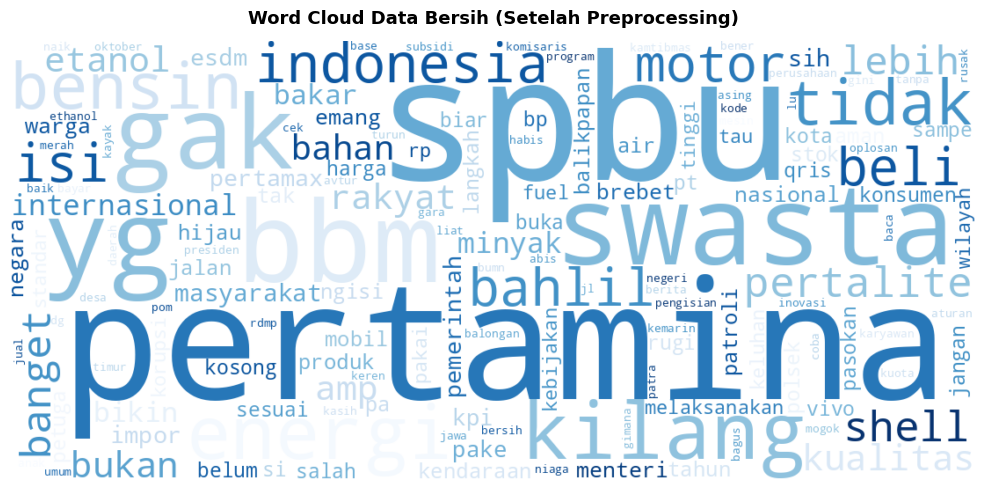

Word cloud disimpan : /content/drive/MyDrive/Proposal Skripsi/dataset/viz_wc_cleaned.png


In [ ]:
# Word cloud data bersih sesudah semua tahap preprocessing
make_wordcloud(
    df['cleaned_text'],
    'Word Cloud Data Bersih (Setelah Preprocessing)',
    BASE + 'viz_wc_cleaned.png',
    colormap='Blues'
)


In [ ]:
# SIMPAN DATASET FINAL PREPROCESSING

save_path = BASE + 'refined.csv'
df.to_csv(save_path, index=False, encoding='utf-8')

print("Dataset final preprocessing berhasil disimpan.")
print(f"Path   : {save_path}")
print(f"Jumlah : {len(df):,} cuitan bersih")


Dataset final preprocessing berhasil disimpan.
Path   : /content/drive/MyDrive/Proposal Skripsi/dataset/refined.csv
Jumlah : 6,642 cuitan bersih


# EKSTRAKSI ASPEK

In [ ]:
# LOAD DATA & DEFINISI POLA ASPEK
# Setiap aspek dideteksi menggunakan Regex-Based Keyword Matching
# berdasarkan kata kunci yang relevan dengan domain Pertamina

import pandas as pd
import re

df = pd.read_csv(BASE + 'refined.csv')
print(f"Data dimuat: {len(df):,} baris")

ASPECT_PATTERNS = {
    'Harga BBM': [
        r'\bharga\b', r'\bnaik harga\b', r'\bturun harga\b',
        r'\bmahal\b', r'\bmurah\b', r'\bsubsidi\b',
        r'\bpertalite\b', r'\bpertamax\b', r'\bsolar\b'
    ],
    'Kualitas BBM': [
        r'\bkualitas\b', r'\bjelek\b', r'\bbagus\b', r'\bair\b',
        r'\bcampur\b', r'\brusak\b', r'\bpalsu\b', r'\boktan\b'
    ],
    'Pelayanan SPBU': [
        r'\bspbu\b', r'\bpelayanan\b', r'\bpetugas\b',
        r'\bantri\b', r'\bantre\b', r'\bramah\b',
        r'\blama\b', r'\bcepat\b', r'\bnomor antrean\b'
    ],
    'Kebijakan Pertamina': [
        r'\bkebijakan\b', r'\baturan\b', r'\bdistribusi\b',
        r'\bkuota\b', r'\bpemerintah\b', r'\bpenetapan\b',
        r'\bregulasi\b', r'\bmenteri\b', r'\bdireksi\b',
        r'\bmanajemen\b', r'\bbahlil\b'
    ],
}

def detect_aspect(text):
    text = str(text).lower()
    found = []
    for aspect, patterns in ASPECT_PATTERNS.items():
        for p in patterns:
            if re.search(p, text):
                found.append(aspect)
                break
    return found if found else ['Umum']

df['aspect'] = df['cleaned_text'].apply(detect_aspect)
df = df.explode('aspect').reset_index(drop=True)
df = df.drop_duplicates(subset=['cleaned_text', 'aspect']).reset_index(drop=True)

print(f"Ekstraksi aspek selesai. Total baris: {len(df):,}")


Data dimuat: 6,642 baris
Ekstraksi aspek selesai. Total baris: 8,198


In [ ]:
# TABEL DISTRIBUSI ASPEK & SIMPAN HASIL

aspect_counts = df['aspect'].value_counts().reset_index()
aspect_counts.columns = ['Aspek', 'Jumlah Data']
aspect_counts['Persentase (%)'] = (
    aspect_counts['Jumlah Data'] / aspect_counts['Jumlah Data'].sum() * 100
).round(1).astype(str) + '%'

total_row = pd.DataFrame([{
    'Aspek': 'Total',
    'Jumlah Data': aspect_counts['Jumlah Data'].sum(),
    'Persentase (%)': '100.0%'
}])
aspect_table = pd.concat([aspect_counts, total_row], ignore_index=True)

print("=" * 52)
print("TABEL 4.3 — Distribusi Data Berdasarkan Aspek")
print("=" * 52)
display(aspect_table)

df.to_csv(BASE + 'aspect_extraction.csv', index=False, encoding='utf-8')
print(f"\nFile disimpan : aspect_extraction.csv ({len(df):,} baris)")


TABEL 4.3 — Distribusi Data Berdasarkan Aspek


,Aspek,Jumlah Data,Persentase (%)
0,Pelayanan SPBU,3856,47.0%
1,Umum,2091,25.5%
2,Kebijakan Pertamina,876,10.7%
3,Harga BBM,740,9.0%
4,Kualitas BBM,635,7.7%
5,Total,8198,100.0%



File disimpan : aspect_extraction.csv (8,198 baris)


# KLASIFIKASI SENTIMEN (IndoBERTweet)

In [ ]:
# LOAD MODEL IndoBERTweet
# Model   : Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis
# Source  : https://huggingface.co/Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis

!pip install -U transformers tqdm -q

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from tqdm import tqdm
import pandas as pd

MODEL_NAME = "Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    truncation=True,
    padding=True
)

df = pd.read_csv(BASE + 'aspect_extraction.csv')
print(f"Model dan data siap.")
print(f"Jumlah data : {len(df):,} baris")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 28.7 MB/s eta 0:00:00


config.json:   0%|          | 0.00/994 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model dan data siap.
Jumlah data : 8,198 baris


In [ ]:
# KLASIFIKASI SENTIMEN

LABEL_MAP = {'POSITIVE': 'Positive', 'NEGATIVE': 'Negative', 'NEUTRAL': 'Neutral'}

sentiments = []
for text in tqdm(df['cleaned_text'], desc='Menganalisis sentimen'):
    try:
        result = sentiment_analyzer(str(text))[0]
        sentiments.append(LABEL_MAP.get(result['label'], result['label']))
    except Exception:
        sentiments.append('Neutral')

df['sentiment'] = sentiments

output_path = BASE + 'hasil_sentimen_indobertweet.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f"\nKlasifikasi sentimen selesai.")
print(f"File disimpan : {output_path}")
print()
print("Distribusi sentimen:")
print(df['sentiment'].value_counts().to_string())


Menganalisis sentimen: 100%|██████████| 8198/8198 [17:59<00:00,  7.60it/s]



Klasifikasi sentimen selesai.
File disimpan : /content/drive/MyDrive/Proposal Skripsi/dataset/hasil_sentimen_indobertweet.csv

Distribusi sentimen:
sentiment
Negative    3707
Neutral     3457
Positive    1034


In [ ]:
# TABEL DISTRIBUSI SENTIMEN KESELURUHAN (Tabel 4.4)

col_order  = [c for c in ['Negative', 'Neutral', 'Positive'] if c in df['sentiment'].unique()]
sent_counts = df['sentiment'].value_counts().reindex(col_order)
sent_pct    = (sent_counts / sent_counts.sum() * 100).round(2)

dist_table = pd.DataFrame({
    'Sentimen'      : sent_counts.index,
    'Jumlah Data'   : sent_counts.values,
    'Persentase (%)': sent_pct.values
})
total_row = pd.DataFrame([{
    'Sentimen'      : 'Total',
    'Jumlah Data'   : dist_table['Jumlah Data'].sum(),
    'Persentase (%)': 100.0
}])
dist_table = pd.concat([dist_table, total_row], ignore_index=True)

print("=" * 52)
print("TABEL 4.4 — Distribusi Sentimen Keseluruhan")
print("=" * 52)
display(dist_table)


TABEL 4.4 — Distribusi Sentimen Keseluruhan


,Sentimen,Jumlah Data,Persentase (%)
0,Negative,3707,45.22
1,Neutral,3457,42.17
2,Positive,1034,12.61
3,Total,8198,100.00


In [ ]:
# TABEL DISTRIBUSI SENTIMEN PER ASPEK (Tabel 4.5)

aspect_sent = pd.crosstab(df['aspect'], df['sentiment'])
aspect_sent = aspect_sent[[c for c in col_order if c in aspect_sent.columns]]
aspect_sent.loc['Total'] = aspect_sent.sum()

print("=" * 56)
print("TABEL 4.5 — Distribusi Sentimen per Aspek")
print("=" * 56)
display(aspect_sent)

aspect_sent.to_csv(BASE + 'distribusi_sentimen_aspek.csv')
print(f"\nFile disimpan : distribusi_sentimen_aspek.csv")


TABEL 4.5 — Distribusi Sentimen per Aspek


sentiment,Negative,Neutral,Positive
aspect,,,
Harga BBM,353,356,31
Kebijakan Pertamina,485,363,28
Kualitas BBM,349,209,77
Pelayanan SPBU,1752,1795,309
Umum,768,734,589
Total,3707,3457,1034



File disimpan : distribusi_sentimen_aspek.csv


# VISUALISASI HASIL ANALISIS

In [ ]:
# SETUP VISUALISASI
# Import library, load data hasil sentimen, dan definisikan konfigurasi warna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

PALETTE   = {'Negative': '#E74C3C', 'Neutral': '#3498DB', 'Positive': '#2ECC71'}
FONT_BOLD = {'fontweight': 'bold'}
DPI       = 150

df = pd.read_csv(BASE + 'hasil_sentimen_indobertweet.csv')
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

col_order   = [c for c in ['Negative', 'Neutral', 'Positive'] if c in df['sentiment'].unique()]
aspect_sent = pd.crosstab(df['aspect'], df['sentiment'])
aspect_sent = aspect_sent[[c for c in col_order if c in aspect_sent.columns]]

print(f"Data siap. Total baris: {len(df):,}")


Data siap. Total baris: 8,198


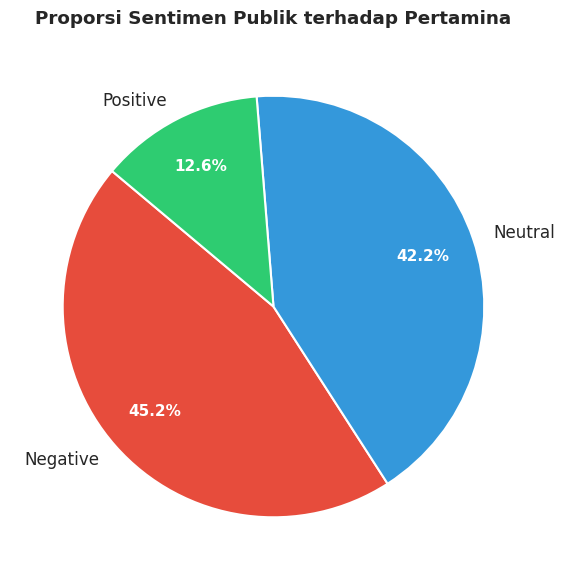

Gambar disimpan: viz_pie_sentimen.png


In [ ]:
# GAMBAR 4.1 — Diagram Lingkaran Proporsi Sentimen Keseluruhan

sent_counts = df['sentiment'].value_counts().reindex(col_order)

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sent_counts,
    labels=sent_counts.index,
    colors=[PALETTE[s] for s in sent_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
    t.set_color('white')

ax.set_title('Proporsi Sentimen Publik terhadap Pertamina', pad=14, **FONT_BOLD)
plt.tight_layout()
plt.savefig(BASE + 'viz_pie_sentimen.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Gambar disimpan: viz_pie_sentimen.png')


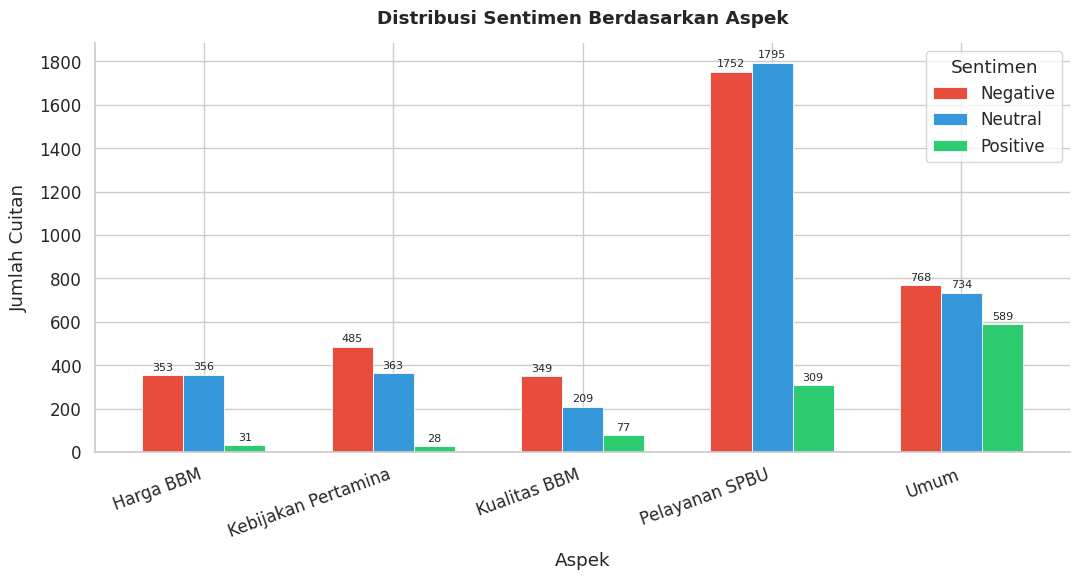

Gambar disimpan: viz_bar_aspek.png


In [ ]:
# GAMBAR 4.2 — Diagram Batang Distribusi Sentimen per Aspek

fig, ax = plt.subplots(figsize=(11, 6))
aspect_sent.plot(
    kind='bar',
    ax=ax,
    color=[PALETTE[c] for c in aspect_sent.columns],
    width=0.65,
    edgecolor='white',
    linewidth=0.6,
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8, padding=2)

ax.set_title('Distribusi Sentimen Berdasarkan Aspek', pad=14, **FONT_BOLD)
ax.set_xlabel('Aspek', labelpad=8)
ax.set_ylabel('Jumlah Cuitan', labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Sentimen', framealpha=0.8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()
plt.tight_layout()

plt.savefig(BASE + 'viz_bar_aspek.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Gambar disimpan: viz_bar_aspek.png')


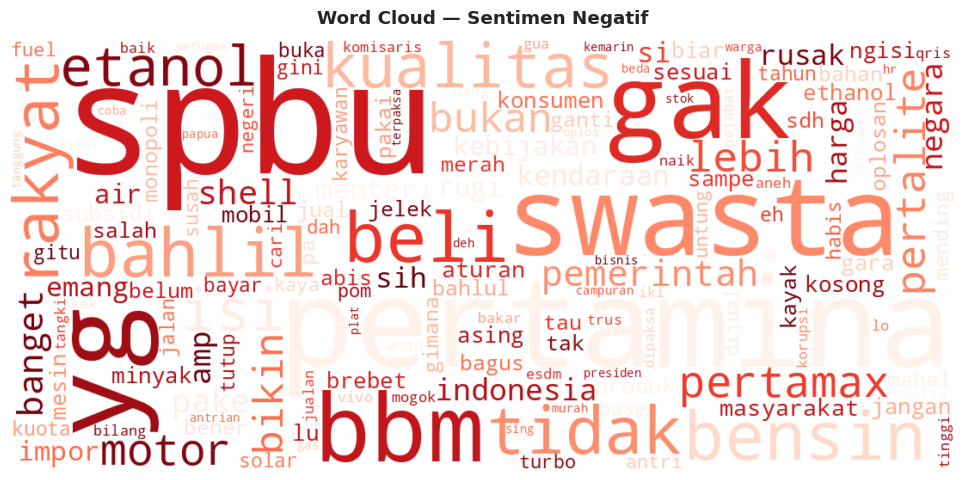

Gambar disimpan: viz_wc_negative.png


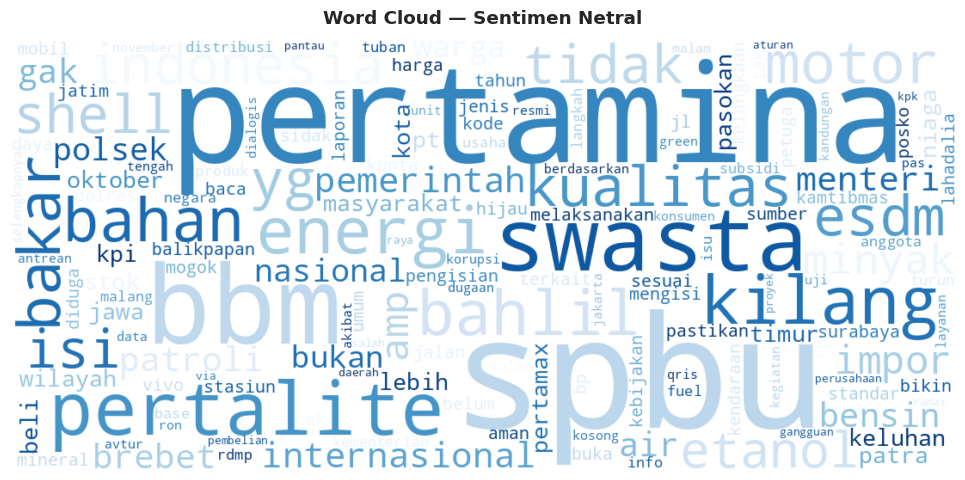

Gambar disimpan: viz_wc_neutral.png


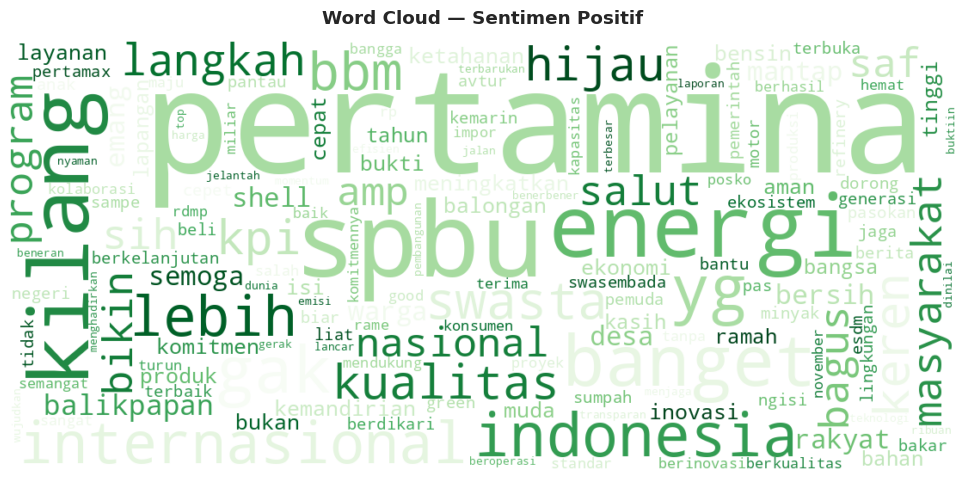

Gambar disimpan: viz_wc_positive.png


In [ ]:
# GAMBAR 4.3, 4.4, 4.5 — Word Cloud per Kategori Sentimen

WC_CONFIG = {
    'Negative': ('Negatif',  'Reds',   'viz_wc_negative.png'),
    'Neutral' : ('Netral',   'Blues',  'viz_wc_neutral.png'),
    'Positive': ('Positif',  'Greens', 'viz_wc_positive.png'),
}

for sent, (label_id, colormap, filename) in WC_CONFIG.items():
    if sent not in df['sentiment'].values:
        continue
    text = ' '.join(df[df['sentiment'] == sent]['cleaned_text'].dropna().astype(str))
    if not text.strip():
        continue
    wc = WordCloud(
        width=1100, height=500,
        background_color='white',
        colormap=colormap,
        max_words=150,
        collocations=False,
    ).generate(text)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — Sentimen {label_id}', pad=12, **FONT_BOLD)
    plt.tight_layout()
    plt.savefig(BASE + filename, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'Gambar disimpan: {filename}')


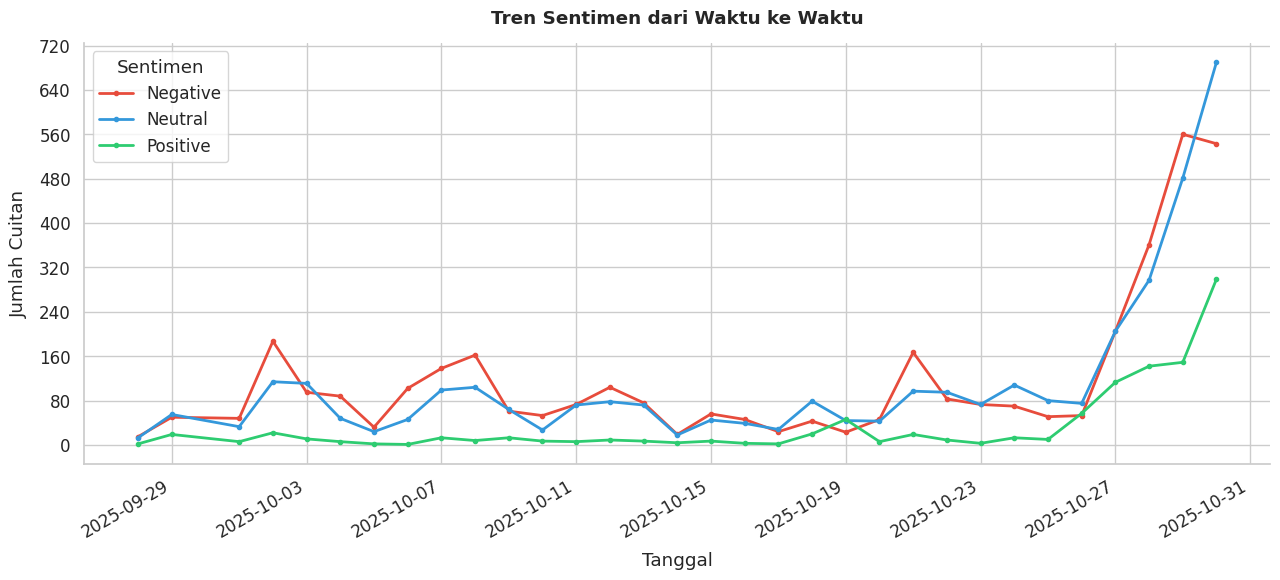

Gambar disimpan: viz_tren_sentimen.png


In [ ]:
# GAMBAR 4.6 — Tren Sentimen dari Waktu ke Waktu

trend = (
    df.groupby([df['created_at'].dt.date, 'sentiment'])
    .size()
    .unstack(fill_value=0)
)
trend = trend[[c for c in col_order if c in trend.columns]]

fig, ax = plt.subplots(figsize=(13, 6))
for col in trend.columns:
    ax.plot(
        trend.index, trend[col],
        label=col,
        color=PALETTE[col],
        linewidth=2,
        marker='o', markersize=3,
    )
ax.set_title('Tren Sentimen dari Waktu ke Waktu', pad=14, **FONT_BOLD)
ax.set_xlabel('Tanggal', labelpad=8)
ax.set_ylabel('Jumlah Cuitan', labelpad=8)
ax.legend(title='Sentimen', framealpha=0.8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
plt.xticks(rotation=30, ha='right')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()
plt.tight_layout()
plt.savefig(BASE + 'viz_tren_sentimen.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Gambar disimpan: viz_tren_sentimen.png')


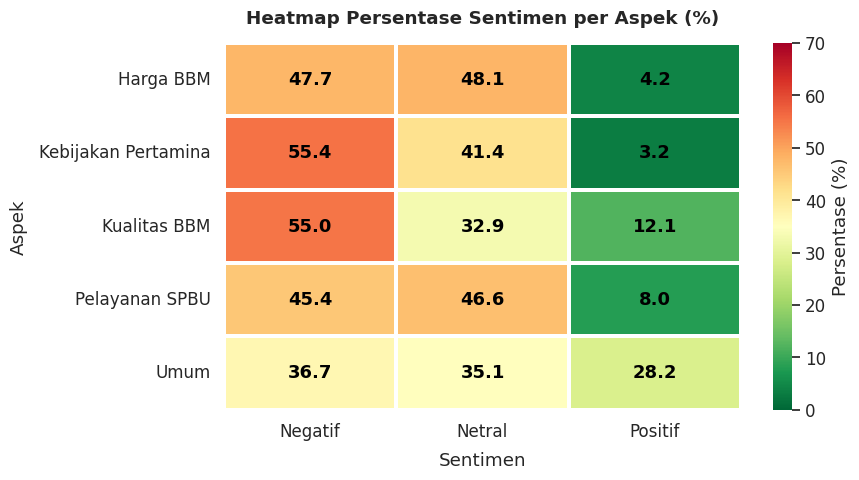

Gambar disimpan: viz_heatmap.png


In [ ]:
# GAMBAR 4.7 — Heatmap Persentase Sentimen per Aspek

aspect_pct = aspect_sent.div(aspect_sent.sum(axis=1), axis=0) * 100
aspect_pct = aspect_pct.round(1)

aspect_pct_id = aspect_pct.rename(columns={
    'Negative': 'Negatif',
    'Neutral' : 'Netral',
    'Positive': 'Positif'
})[['Negatif', 'Netral', 'Positif']]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    aspect_pct_id,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=1.5, linecolor='white',
    cbar_kws={'label': 'Persentase (%)'},
    ax=ax, vmin=0, vmax=70,
    annot_kws={'size': 13, 'weight': 'bold', 'color': 'black'}
)
ax.set_title('Heatmap Persentase Sentimen per Aspek (%)', pad=14, **FONT_BOLD)
ax.set_xlabel('Sentimen', labelpad=8)
ax.set_ylabel('Aspek', labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(BASE + 'viz_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Gambar disimpan: viz_heatmap.png')


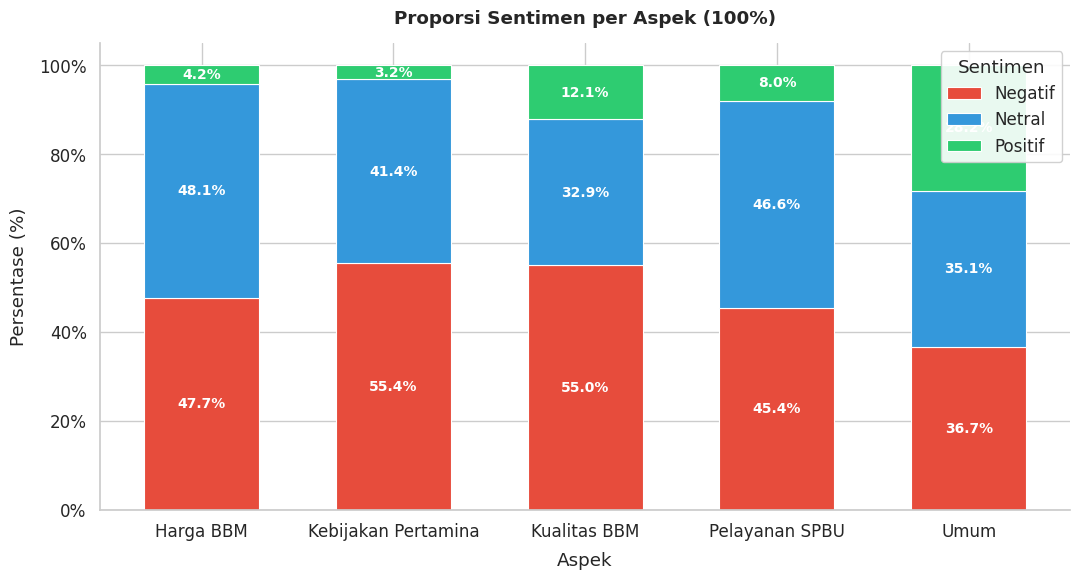

Gambar disimpan: viz_stacked100.png


In [ ]:
# GAMBAR 4.8 — Stacked Bar 100% Proporsi Sentimen per Aspek

neg_v  = aspect_pct['Negative'].values
neut_v = aspect_pct['Neutral'].values
pos_v  = aspect_pct['Positive'].values
labels = aspect_pct.index.tolist()
x      = np.arange(len(labels))
w      = 0.6

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x, neg_v,  width=w, label='Negatif', color='#E74C3C', edgecolor='white', linewidth=0.8)
b2 = ax.bar(x, neut_v, width=w, bottom=neg_v,           label='Netral',  color='#3498DB', edgecolor='white', linewidth=0.8)
b3 = ax.bar(x, pos_v,  width=w, bottom=neg_v + neut_v,  label='Positif', color='#2ECC71', edgecolor='white', linewidth=0.8)

for bars, vals, bots in [(b1, neg_v, np.zeros(len(x))),
                          (b2, neut_v, neg_v),
                          (b3, pos_v, neg_v + neut_v)]:
    for bar, v, bot in zip(bars, vals, bots):
        if v >= 3:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bot + v / 2,
                f'{v:.1f}%',
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white'
            )

ax.set_title('Proporsi Sentimen per Aspek (100%)', pad=14, **FONT_BOLD)
ax.set_xlabel('Aspek', labelpad=8)
ax.set_ylabel('Persentase (%)', labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v)}%'))
ax.legend(title='Sentimen', framealpha=0.9, loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig(BASE + 'viz_stacked100.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Gambar disimpan: viz_stacked100.png')


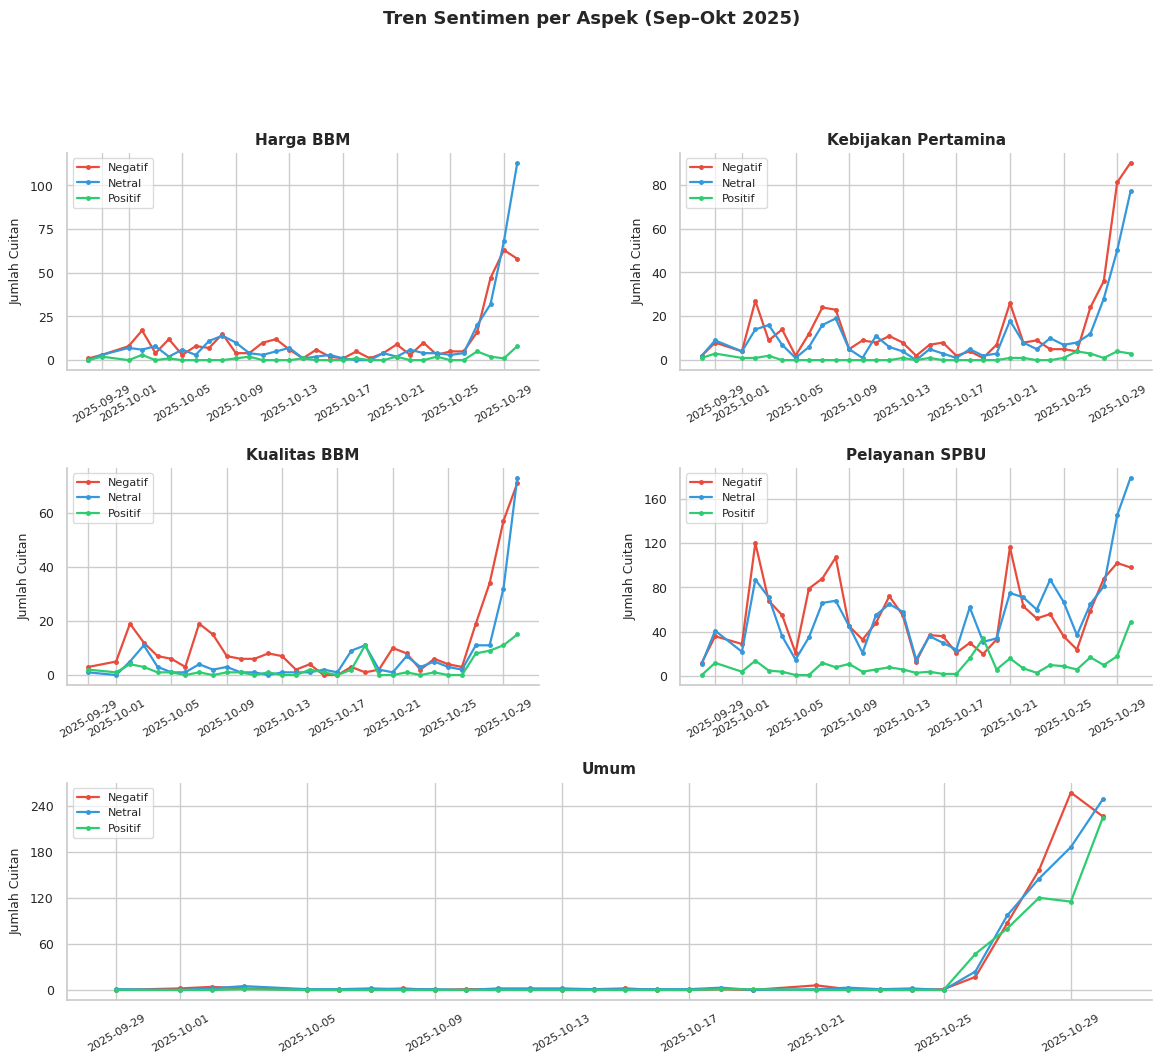

Gambar disimpan: viz_tren_aspek.png


In [ ]:
# GAMBAR 4.9 — Tren Sentimen per Aspek

trend_asp = (
    df.groupby([df['created_at'].dt.date, 'aspect', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'Negative': 'Negatif', 'Neutral': 'Netral', 'Positive': 'Positif'})
)
sent_id  = [s for s in ['Negatif', 'Netral', 'Positif'] if s in trend_asp.columns]
SENT_CLR = {'Negatif': '#E74C3C', 'Netral': '#3498DB', 'Positif': '#2ECC71'}
aspects  = ['Harga BBM', 'Kebijakan Pertamina', 'Kualitas BBM', 'Pelayanan SPBU', 'Umum']

fig = plt.figure(figsize=(14, 11))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)
axes_map = {
    'Harga BBM'          : fig.add_subplot(gs[0, 0]),
    'Kebijakan Pertamina': fig.add_subplot(gs[0, 1]),
    'Kualitas BBM'       : fig.add_subplot(gs[1, 0]),
    'Pelayanan SPBU'     : fig.add_subplot(gs[1, 1]),
    'Umum'               : fig.add_subplot(gs[2, :]),
}

for asp, ax in axes_map.items():
    try:
        grp = trend_asp.xs(asp, level='aspect')
    except KeyError:
        ax.set_visible(False)
        continue
    for sent in sent_id:
        if sent in grp.columns:
            ax.plot(grp.index, grp[sent], label=sent,
                    color=SENT_CLR[sent], linewidth=1.6, marker='o', markersize=2.5)
    ax.set_title(asp, fontsize=11, fontweight='bold')
    ax.set_ylabel('Jumlah Cuitan', fontsize=9, labelpad=5)
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=9)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))
    sns.despine(ax=ax)

fig.suptitle('Tren Sentimen per Aspek (Sep–Okt 2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(BASE + 'viz_tren_aspek.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Gambar disimpan: viz_tren_aspek.png')


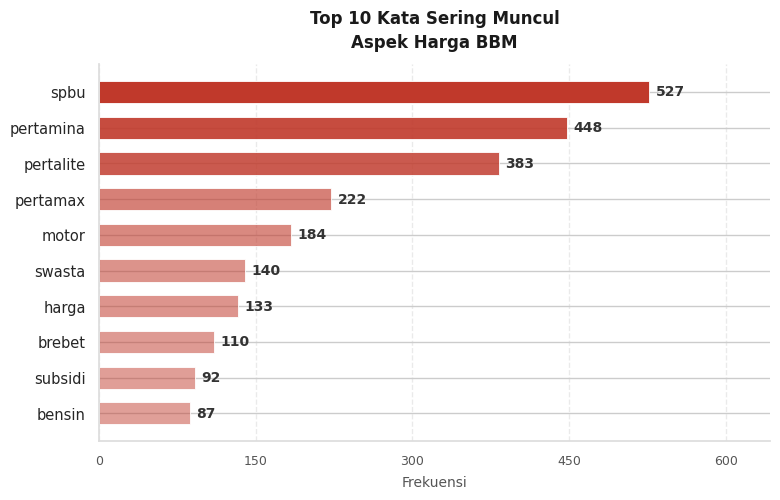

Gambar disimpan : viz_top10_harga_bbm.png
Top kata        : ['spbu', 'pertamina', 'pertalite', 'pertamax', 'motor', 'swasta', 'harga', 'brebet', 'subsidi', 'bensin']



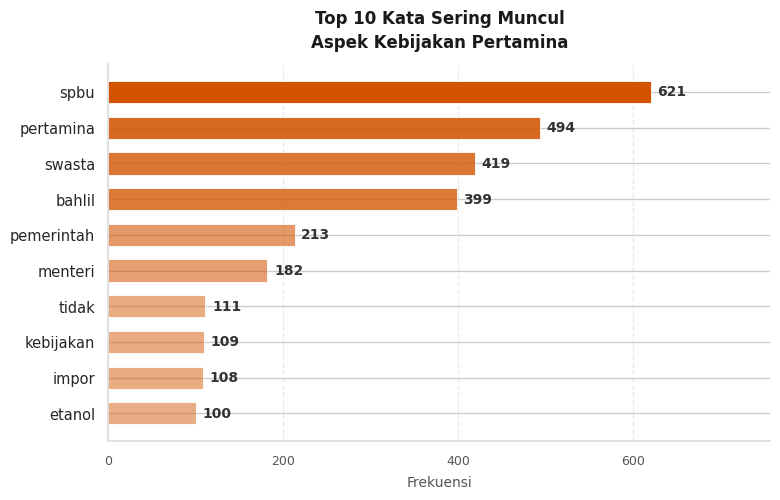

Gambar disimpan : viz_top10_kebijakan_pertamina.png
Top kata        : ['spbu', 'pertamina', 'swasta', 'bahlil', 'pemerintah', 'menteri', 'tidak', 'kebijakan', 'impor', 'etanol']



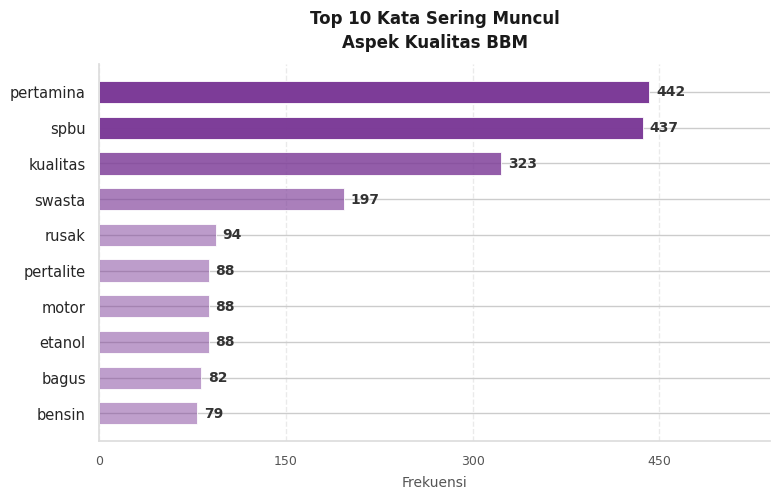

Gambar disimpan : viz_top10_kualitas_bbm.png
Top kata        : ['pertamina', 'spbu', 'kualitas', 'swasta', 'rusak', 'pertalite', 'motor', 'etanol', 'bagus', 'bensin']



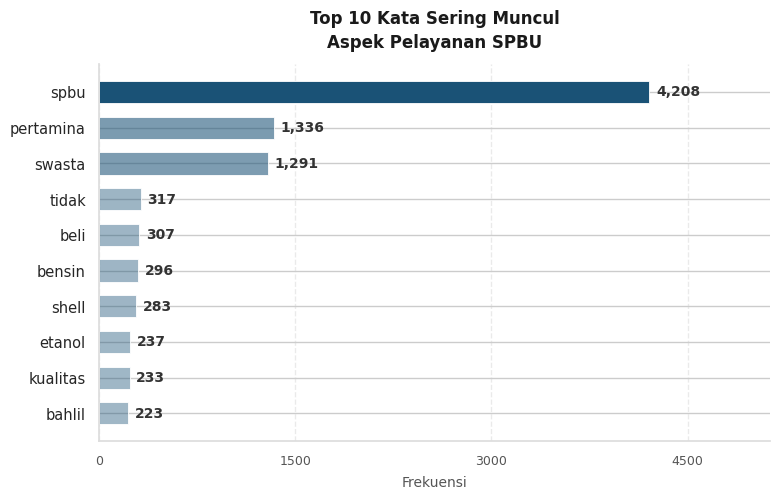

Gambar disimpan : viz_top10_pelayanan_spbu.png
Top kata        : ['spbu', 'pertamina', 'swasta', 'tidak', 'beli', 'bensin', 'shell', 'etanol', 'kualitas', 'bahlil']



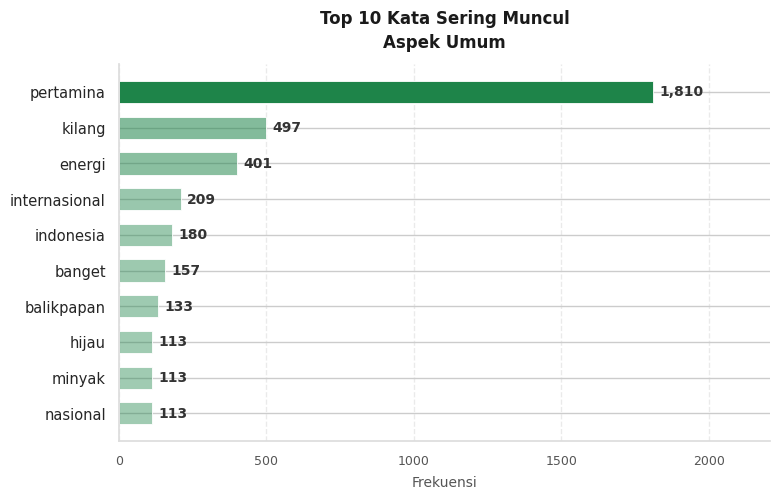

Gambar disimpan : viz_top10_umum.png
Top kata        : ['pertamina', 'kilang', 'energi', 'internasional', 'indonesia', 'banget', 'balikpapan', 'hijau', 'minyak', 'nasional']

Semua gambar Top 10 Kata per Aspek selesai.


In [ ]:
# GAMBAR 4.10 s.d. 4.14 — Top 10 Kata per Aspek

from collections import Counter

def top_words(texts, n=10):
    """Ambil n kata paling sering muncul dari kumpulan teks."""
    words = []
    for t in texts:
        if pd.isna(t):
            continue
        tokens = re.findall(r'\b[a-zA-Z]{4,}\b', str(t).lower())
        words.extend(tokens)
    return Counter(words).most_common(n)

ASPECT_CONFIG = {
    'Harga BBM'          : {'color': '#C0392B', 'filename': 'viz_top10_harga_bbm.png'},
    'Kebijakan Pertamina': {'color': '#D35400', 'filename': 'viz_top10_kebijakan_pertamina.png'},
    'Kualitas BBM'       : {'color': '#7D3C98', 'filename': 'viz_top10_kualitas_bbm.png'},
    'Pelayanan SPBU'     : {'color': '#1A5276', 'filename': 'viz_top10_pelayanan_spbu.png'},
    'Umum'               : {'color': '#1E8449', 'filename': 'viz_top10_umum.png'},
}

for asp, cfg in ASPECT_CONFIG.items():
    sub = df[df['aspect'] == asp]['cleaned_text']
    top = top_words(sub, n=10)
    if not top:
        print(f'Tidak ada data untuk aspek: {asp}')
        continue

    words_list = [w for w, _ in top][::-1]
    counts     = [c for _, c in top][::-1]
    color      = cfg['color']
    mx         = max(counts)
    base_rgb   = tuple(int(color.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))
    bar_colors = [(*base_rgb, 0.38 + 0.62 * (v / mx)) for v in counts]

    fig, ax = plt.subplots(figsize=(8, 5.2))
    fig.patch.set_facecolor('white')
    bars = ax.barh(words_list, counts, color=bar_colors,
                   edgecolor='white', linewidth=0.6, height=0.62)

    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() + mx * 0.012,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', ha='left',
                fontsize=10, fontweight='bold', color='#333333')

    ax.set_title(f'Top 10 Kata Sering Muncul\nAspek {asp}',
                 fontsize=12, fontweight='bold', color='#1A1A1A', pad=12, linespacing=1.4)
    ax.set_xlabel('Frekuensi', fontsize=10, color='#555555', labelpad=6)
    ax.set_xlim(0, mx * 1.22)
    ax.tick_params(axis='y', labelsize=10.5)
    ax.tick_params(axis='x', labelsize=9, colors='#555555')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))
    ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='#BBBBBB')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')
    plt.tight_layout()
    plt.savefig(BASE + cfg['filename'], dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Gambar disimpan : {cfg['filename']}")
    print(f"Top kata        : {[w for w, _ in top]}")
    print()

print('Semua gambar Top 10 Kata per Aspek selesai.')
